# Skin Tissue Visualization

Publication-quality ellipse plots with separate legend export.

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from pathlib import Path

## Configuration

In [23]:
# ── Data path ──
DATA_FOLDER = Path("advanced_skin_output_high")

# ── Background: 'white' or 'black' ──
BACKGROUND = "white"  # change to "black" for dark background

# ── Global cell size scale factor ──
# Values < 1.0 shrink cells, > 1.0 enlarge them
CELL_SIZE_SCALE = 0.8

# ── Output paths (auto-suffixed with background) ──
OUT_PLOT = DATA_FOLDER / f"skin_ellipse_{BACKGROUND}.pdf"
OUT_LEGEND = DATA_FOLDER / f"skin_legend_{BACKGROUND}.pdf"

## Constants (mirrored from generate_advanced_skin.py)

In [24]:
SCALE_FACTOR = 1.0
FRAME_WIDTH = int(800 * SCALE_FACTOR)
FRAME_HEIGHT = int(1000 * SCALE_FACTOR)

# Layer depths (µm)
DEJ_DEPTH = int(100 * SCALE_FACTOR)
PAPILLARY_DERMIS_DEPTH = int(200 * SCALE_FACTOR)
RETICULAR_DERMIS_DEPTH = int(800 * SCALE_FACTOR)

# Coarse layer boundaries (only the major ones)
LAYER_DEPTHS = [
    DEJ_DEPTH,
    PAPILLARY_DERMIS_DEPTH,
    RETICULAR_DERMIS_DEPTH,
]

# Coarse layer labels
LAYER_LABELS = [
    (DEJ_DEPTH / 2, 'Epidermis'),
    ((DEJ_DEPTH + PAPILLARY_DERMIS_DEPTH) / 2, 'Papillary Dermis'),
    ((PAPILLARY_DERMIS_DEPTH + RETICULAR_DERMIS_DEPTH) / 2, 'Reticular Dermis'),
    ((RETICULAR_DERMIS_DEPTH + FRAME_HEIGHT) / 2, 'Hypodermis'),
]

N_CELL_TYPES = 20

CELL_TYPE_NAMES = [
    'Keratinocyte_Cornified',
    'Keratinocyte_Granular',
    'Keratinocyte_Spinous',
    'Keratinocyte_Basal',
    'Melanocyte',
    'Fibroblast_Papillary',
    'Fibroblast_Reticular',
    'Endothelial',
    'Pericyte',
    'Sebocyte',
    'Sweat_Eccrine',
    'Sweat_Apocrine',
    'Hair',
    'Hair_Unused',
    'Adipocyte',
    'Langerhans',
    'Macrophage',
    'T_Cell',
    'Mast_Cell',
    'Sensory_Corpuscle',
]

CELL_TYPE_COLORS = {
    0:  '#FF1493',  # Keratinocyte_Cornified
    1:  '#FF6347',  # Keratinocyte_Granular
    2:  '#FF8C00',  # Keratinocyte_Spinous
    3:  '#FFD700',  # Keratinocyte_Basal
    4:  '#8B4513',  # Melanocyte
    5:  '#00FF00',  # Fibroblast_Papillary
    6:  '#006400',  # Fibroblast_Reticular
    7:  '#FF0000',  # Endothelial
    8:  '#DC143C',  # Pericyte
    9:  '#FFFF00',  # Sebocyte
    10: '#0000FF',  # Sweat_Eccrine
    11: '#00BFFF',  # Sweat_Apocrine
    12: '#FF00FF',  # Hair
    13: '#FF1493',  # Hair_Unused
    14: '#FFA500',  # Adipocyte
    15: '#9370DB',  # Langerhans
    16: '#BA55D3',  # Macrophage
    17: '#8A2BE2',  # T_Cell
    18: '#DA70D6',  # Mast_Cell
    19: '#00FFFF',  # Sensory_Corpuscle
}

## Load data

In [25]:
cells_df = pd.read_csv(DATA_FOLDER / "cells.csv")
print(f"Loaded {len(cells_df)} cells")
cells_df.head()

Loaded 7542 cells


,X,Y,Class ID,Class 0,Class 1,Class 2,Class 3,Class 4,Class 5,Class 6,...,ProbClass15,ProbClass16,ProbClass17,ProbClass18,ProbClass19,Minor Axis,Major Axis,Rotation,RNA Concentration,Color_string
0,79.669140,780.395230,14,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,22.655853,28.681906,2.241596,0.908286,"(np.float64(0.4980392156862745), np.float64(0...."
1,202.665079,781.734778,14,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,22.821087,26.732772,1.206981,0.621501,"(np.float64(0.4980392156862745), np.float64(0...."
2,320.325114,779.271291,14,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,21.499399,29.008945,3.006235,0.502311,"(np.float64(0.4980392156862745), np.float64(0...."
3,536.836473,779.558896,14,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,19.548508,30.462908,2.351091,0.612435,"(np.float64(0.4980392156862745), np.float64(0...."
4,554.539913,782.228843,14,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,25.934915,23.032835,2.124280,1.213007,"(np.float64(0.4980392156862745), np.float64(0...."


## Ellipse plot

Saved: advanced_skin_output_high/skin_ellipse_white.pdf


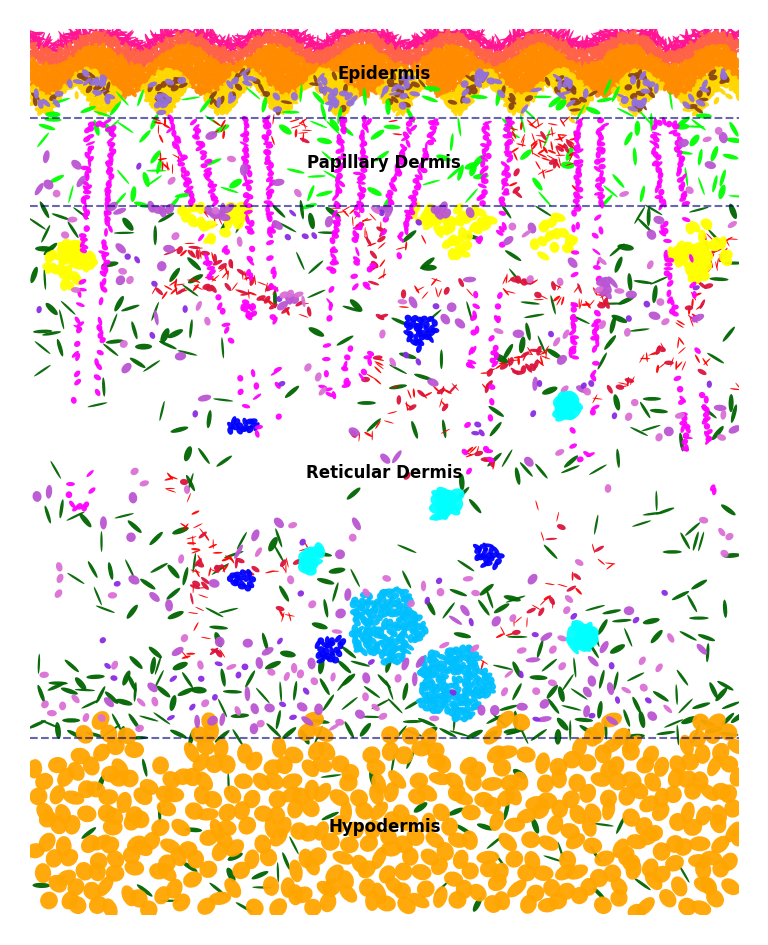

In [26]:
matplotlib.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
})

mm_to_in = 1 / 25.4
fig_size = 60 * mm_to_in

# Derive colors from background
if BACKGROUND == "black":
    text_color = "white"
    layer_line_color = "cyan"
else:
    text_color = "black"
    layer_line_color = "navy"

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 1.5), dpi=300)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.set_facecolor(BACKGROUND)
fig.patch.set_facecolor(BACKGROUND)

# Render ellipses grouped by cell type
for ct in range(N_CELL_TYPES):
    mask = cells_df["Class ID"] == ct
    if mask.sum() == 0:
        continue
    cells_ct = cells_df[mask]
    patches = []
    for _, cell in cells_ct.iterrows():
        patches.append(Ellipse(
            xy=(cell["X"], cell["Y"]),
            width=cell["Major Axis"] * CELL_SIZE_SCALE,
            height=cell["Minor Axis"] * CELL_SIZE_SCALE,
            angle=np.degrees(cell["Rotation"]),
        ))
    collection = PatchCollection(
        patches,
        facecolors=CELL_TYPE_COLORS[ct],
        edgecolors="none",
        alpha=0.95,
    )
    ax.add_collection(collection)

ax.set_xlim(0, FRAME_WIDTH)
ax.set_ylim(0, FRAME_HEIGHT)
ax.set_aspect("equal")
ax.invert_yaxis()

# Remove all axes, ticks, spines
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Layer boundary lines
for depth in LAYER_DEPTHS:
    ax.axhline(y=depth, color=layer_line_color, ls="--", lw=0.5, alpha=0.6)

# Layer labels (centered horizontally in the frame)
for y_pos, label_text in LAYER_LABELS:
    ax.text(FRAME_WIDTH / 2, y_pos, label_text, fontsize=4, color=text_color,
            fontweight="bold", va="center", ha="center")

fig.savefig(OUT_PLOT, dpi=300, bbox_inches="tight", pad_inches=0, facecolor=BACKGROUND)
print(f"Saved: {OUT_PLOT}")
plt.show()

## Separate legend

Saved: advanced_skin_output_high/skin_legend_black.pdf


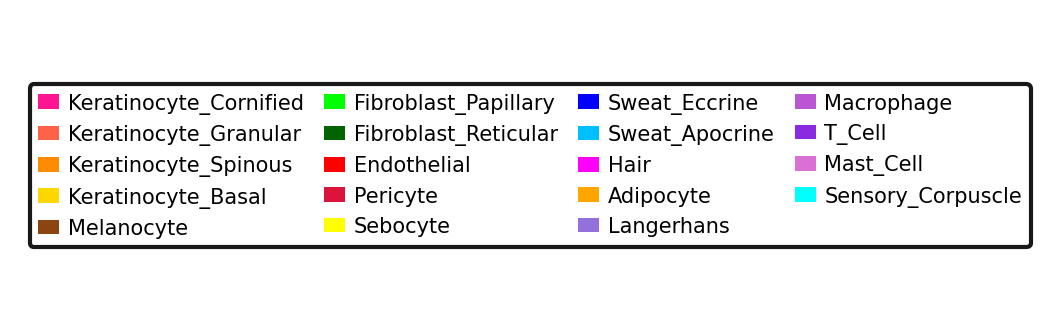

In [22]:
# Build legend handles for cell types present in the data
present_cts = sorted(cells_df["Class ID"].unique())
legend_handles = [
    Patch(facecolor=CELL_TYPE_COLORS[ct], edgecolor="none",
          label=CELL_TYPE_NAMES[ct])
    for ct in present_cts
]

fig_leg, ax_leg = plt.subplots(
    figsize=(fig_size, fig_size * 0.5), dpi=300
)
ax_leg.set_facecolor('white')
fig_leg.patch.set_facecolor('white')
ax_leg.axis("off")

legend = ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=4,
    fontsize=5,
    frameon=True,
    framealpha=0.9,
    edgecolor='black',
    facecolor='white',
    labelcolor='black',
    handlelength=1.0,
    handletextpad=0.4,
    columnspacing=1.0,
)

fig_leg.savefig(OUT_LEGEND, dpi=300, bbox_inches="tight", facecolor='white')
print(f"Saved: {OUT_LEGEND}")
plt.show()